# H7 Hub Coupling Exploration

This notebook is scoped to **H7: are structural hubs also functional hubs?** It uses the same 906-neuron cohort and functional cache expected by the final team notebook, but only implements the H7 workflow. The analysis is written to preserve negative results: if a stricter definition of functional hubness is null, that is treated as part of the answer rather than set aside.

Up-front conclusion after the full analysis: the broad H7 interpretation is not strongly supported. The synapse-size structural strength proxy contributes no detectable variance beyond binary connectivity, and structural hubness is not associated with sign-agnostic absolute `F_corr` or thresholded functional graph topology. A narrower signed result remains: excitatory neurons with higher synapse-size structural strength are slightly more aligned with the cohort's signed oracle-response population mode, explaining about 1% of rank variance. Directional rows suggest an input-side tendency, but the 10k area x layer stratified permutation for `in_strength` is marginal, so this should not be treated as firm directional biology.

Primary conventions for this notebook:

- The cohort is exclusively `excitatory_neuron`, so all H7 claims are within excitatory neurons only and do not generalize to inhibitory-hub or E/I hub hypotheses.
- The 906-neuron functional matrix is Pearson signal correlation across aligned oracle stimulus responses. It is not same-session trace correlation and not noise correlation.
- Structural matrix `C_strength[pre, post]` uses summed synapse `size` as a **synapse-size structural strength proxy**. It is not a direct physiological synaptic-weight or EPSC measurement.
- Degree is still reported as topology: an edge exists when `C_strength[pre, post] > 0`.
- The primary functional metric is mean signed `F_corr` to the rest of the cohort, used here as signed **population-mode alignment** or positive signal similarity to the cohort. This is **not** the same as sign-agnostic functional coupling magnitude, so absolute and positive-clipped alternatives are explicitly tested.
- Distance, area, and layer controls are included because they could affect H7 validity. Layer control is interpreted as a strict sensitivity check because layer can be both a confounder and part of the biological mechanism.
- Thresholded functional topology is exploratory and density-sensitive. If thresholded graph metrics are null, we do **not** claim similar structural and functional graph topology.


---
## 1. Setup

The loading code follows the current `final_structure_function.ipynb` pattern, but this notebook relies on local caches where possible so H7 can be rerun quickly.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from scipy import sparse, stats
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

warnings.filterwarnings('ignore', category=RuntimeWarning)

DATA_DIR = Path('Data') if Path('Data').exists() else Path('data')
CACHE_DIR = DATA_DIR / 'cache'
SYN_CSV = DATA_DIR / '1718' / 'raw' / 'synapses_matched.csv'
OUT_FIG = Path('outputs/figures')
OUT_TBL = Path('outputs/tables')
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TBL.mkdir(parents=True, exist_ok=True)

PAL_AREA = {'V1': '#4E79A7', 'RL': '#F28E2B', 'AL': '#59A14F'}
RAMP_DIV = plt.get_cmap('RdBu_r')

sns.set_theme(context='notebook', style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})

print('repo root:', Path('.').resolve())
print('data dir :', DATA_DIR.resolve())


repo root: C:\Users\leona\AppData\Local\Programs\Python\Neuro-1
data dir : C:\Users\leona\AppData\Local\Programs\Python\Neuro-1\Data


---
## 2. Load and Validate the 906-Neuron Cohort

H7 must use the same neuron ordering as the functional matrix. The expected row order is `matrix_index` / current DataFrame index. We also print the available neuron class labels: if the cohort is all excitatory, E/I stratification is not a valid H7 analysis for this notebook.

In [2]:
COHORT_PKL = CACHE_DIR / 'matched_906.pkl'
LOCAL_COHORT_CSV = Path('Leo/outputs/structural_network/all-matched_axon-clean/cohort_neurons.csv')

REQUIRED_COHORT_COLS = [
    'pt_root_id', 'brain_area', 'layer', 'cell_type',
    'pt_position_x', 'pt_position_y', 'pt_position_z',
]

def normalize_matched(df):
    df = df.copy()
    if 'matrix_index' in df.columns:
        df = df.sort_values('matrix_index', kind='stable').reset_index(drop=True)
    else:
        df = df.reset_index(drop=True)
    if 'unit_id' not in df.columns and 'functional_unit_id' in df.columns:
        df['unit_id'] = df['functional_unit_id']
    missing = [c for c in REQUIRED_COHORT_COLS if c not in df.columns]
    if missing:
        raise ValueError(f'cohort is missing required columns: {missing}')
    if df.pt_root_id.duplicated().any():
        raise ValueError('cohort has duplicated pt_root_id values')
    df.index.name = 'matrix_index'
    return df

if COHORT_PKL.exists():
    matched = normalize_matched(pd.read_pickle(COHORT_PKL))
    source = COHORT_PKL
elif LOCAL_COHORT_CSV.exists():
    matched = normalize_matched(pd.read_csv(LOCAL_COHORT_CSV))
    matched.to_pickle(COHORT_PKL)
    source = LOCAL_COHORT_CSV
else:
    raise FileNotFoundError(
        'Missing matched 906-neuron cohort. Expected Data/cache/matched_906.pkl '
        'or Leo/outputs/structural_network/all-matched_axon-clean/cohort_neurons.csv.'
    )

assert len(matched) == 906, f'Expected 906 neurons, got {len(matched)}'

print(f'loaded cohort from: {source}')
print(f'n_neurons: {len(matched)}')
print('brain areas:', matched.brain_area.value_counts().to_dict())
print('layers     :', matched.layer.value_counts().to_dict())
if 'classification_system' in matched.columns:
    print('classes    :', matched.classification_system.value_counts(dropna=False).to_dict())
matched.head()


loaded cohort from: Data\cache\matched_906.pkl
n_neurons: 906
brain areas: {'V1': 728, 'RL': 122, 'AL': 56}
layers     : {'L4': 348, 'L2/3': 348, 'L5': 156, 'L6': 53, 'L1': 1}
classes    : {'excitatory_neuron': 906}


,matrix_index,nucleus_id,pt_root_id,classification_system,cell_type,layer,brain_area,strategy_axon,strategy_dendrite,pt_position_x,...,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,cc_max,cc_norm,OSI,DSI
matrix_index,,,,,,,,,,,,,,,,,,,,,
0,0,262198,864691135214931072,excitatory_neuron,4P,L4,V1,axon_partially_extended,dendrite_extended,595.708175,...,8361,128.02513,128.02513,0.297541,0.053234,0.906062,0.940364,0.963523,0.524613,0.142182
1,1,396772,864691135860969064,excitatory_neuron,4P,L4,V1,axon_partially_extended,dendrite_extended,895.713218,...,8306,106.31060,106.31060,0.288733,0.053861,0.891495,0.880552,1.012427,0.518364,0.139082
2,2,396178,864691135977134403,excitatory_neuron,4P,L4,V1,axon_partially_extended,dendrite_extended,910.085473,...,5734,84.24084,84.24084,0.104923,0.124105,0.886413,0.957996,0.925278,0.198533,0.359711
3,3,294715,864691135842486243,excitatory_neuron,23P,L2/3,V1,axon_partially_extended,dendrite_clean,711.321788,...,3120,117.58855,297.58856,0.090670,0.082808,0.883082,0.905513,0.975228,0.200192,0.226150
4,4,394533,864691136138131325,excitatory_neuron,4P,L4,V1,axon_partially_extended,dendrite_extended,880.888106,...,4393,64.15351,64.15351,0.063439,0.069853,0.880466,0.857027,1.027349,0.119525,0.137589


---
## 3. Build the Structural Hub Matrix

For H7, `C_strength[pre, post]` is the directed structural matrix with weight equal to summed source-column `size` from the presynaptic neuron to the postsynaptic neuron. Throughout this notebook, **strength** means this synapse-size structural strength proxy, not measured EPSC amplitude or physiological synaptic weight. Degree is reported separately as binary topology, so the analysis can distinguish a synapse-size-weighted result from a purely topological one.


In [3]:
N = len(matched)
pt_to_idx = pd.Series(matched.index.values, index=matched.pt_root_id.astype('int64'))

syn = pd.read_csv(SYN_CSV)
syn = syn[syn.pre_pt_root_id != syn.post_pt_root_id].copy()
syn = syn[
    syn.pre_pt_root_id.astype('int64').isin(pt_to_idx.index)
    & syn.post_pt_root_id.astype('int64').isin(pt_to_idx.index)
].copy()

rows = pt_to_idx.loc[syn.pre_pt_root_id.astype('int64')].to_numpy()
cols = pt_to_idx.loc[syn.post_pt_root_id.astype('int64')].to_numpy()

C_strength = sparse.coo_matrix(
    (syn['size'].to_numpy(dtype=float), (rows, cols)),
    shape=(N, N),
).tocsr()
A_struct = C_strength != 0

print(f'C_strength shape: {C_strength.shape}')
print(f'directed structural edges: {C_strength.nnz:,}')
print(f'directed density, no autapses: {C_strength.nnz / (N * (N - 1)):.5f}')
print(f'total synapse rows after filters: {len(syn):,}')
print(f'total summed synapse size: {C_strength.sum():,.1f}')


C_strength shape: (906, 906)
directed structural edges: 11,822
directed density, no autapses: 0.01442
total synapse rows after filters: 11,822
total summed synapse size: 110,000,164.0


---
## 4. Load Functional Responses and Compute `F_corr`

`F_906.npy` is the oracle-stimulus response matrix from the current final draft workflow. `F_corr` is Pearson signal correlation across those aligned oracle stimuli. The valid-neuron mask is checked explicitly before any per-neuron means are used.

In [4]:
F_NPY = CACHE_DIR / 'F_906.npy'
F_VALID_NPY = CACHE_DIR / 'F_906_valid.npy'
F_COND_TXT = CACHE_DIR / 'F_906_oracle_conditions.txt'

if not F_NPY.exists() or not F_VALID_NPY.exists():
    raise FileNotFoundError(
        'Missing Data/cache/F_906.npy or Data/cache/F_906_valid.npy. '
        'Run the data-loading section of final_structure_function.ipynb first.'
    )

F = np.load(F_NPY)
valid = np.load(F_VALID_NPY).astype(bool)
assert F.shape[0] == N, f'F rows ({F.shape[0]}) do not match cohort rows ({N})'
assert valid.shape[0] == N, f'valid mask length ({valid.shape[0]}) does not match cohort rows ({N})'
if (~valid).any():
    assert np.isnan(F[~valid]).all(), 'invalid functional rows are not all NaN; mean F_corr would be contaminated'
assert np.isfinite(F[valid]).all(), 'valid functional rows contain non-finite values'

F_corr = np.corrcoef(F)
np.fill_diagonal(F_corr, np.nan)
finite_offdiag = np.isfinite(F_corr)

print(f'F shape: {F.shape}')
print(f'valid functional neurons: {valid.sum()} / {N}')
if F_COND_TXT.exists():
    n_conditions = len(F_COND_TXT.read_text().splitlines())
    print(f'oracle conditions: {n_conditions}')
print(f'finite off-diagonal F_corr entries: {finite_offdiag.sum():,}')
print(f'mean off-diagonal F_corr: {np.nanmean(F_corr):+.4f}')


F shape: (906, 116)
valid functional neurons: 906 / 906
oracle conditions: 116
finite off-diagonal F_corr entries: 819,930
mean off-diagonal F_corr: +0.0232


---
## 5. Compute H7 Hub Metrics

Primary structural hubness is total synapse-size structural strength proxy (`total_strength`). Degree and the in/out split are retained because they test whether the H7 effect reflects synapse-size weighting, binary topology, or a directional tendency. The directional rows are not a standalone conclusion: the `in_strength` partial Spearman is positive, but its 10k area x layer stratified permutation is marginal, so input-side language should stay cautious. A pairwise-distance residualized functional metric is added because node-level mean distance is only a coarse distance control. This residual metric is treated as a diagnostic, not as a guaranteed clean correction: if node-averaged residuals still correlate with node-level mean distance, that limitation is part of the result.


In [5]:
def mean_pairwise_distance_um(xyz):
    dist = np.linalg.norm(xyz[:, None, :] - xyz[None, :, :], axis=2)
    np.fill_diagonal(dist, np.nan)
    return np.nanmean(dist, axis=1)

xyz = matched[['pt_position_x', 'pt_position_y', 'pt_position_z']].to_numpy(dtype=float)
mean_dist_um = mean_pairwise_distance_um(xyz)

F_corr_no_diag = F_corr.copy()
np.fill_diagonal(F_corr_no_diag, np.nan)

mean_fcorr_signed = np.nanmean(F_corr_no_diag, axis=1)
mean_fcorr_pos_clipped = np.nanmean(np.clip(F_corr_no_diag, 0, None), axis=1)
mean_fcorr_abs = np.nanmean(np.abs(F_corr_no_diag), axis=1)

iu_all, ju_all = np.triu_indices(N, k=1)
pair_dist = np.linalg.norm(xyz[iu_all] - xyz[ju_all], axis=1)
pair_fc = F_corr_no_diag[iu_all, ju_all]
pair_mask = np.isfinite(pair_fc) & valid[iu_all] & valid[ju_all]
d_z = (pair_dist[pair_mask] - pair_dist[pair_mask].mean()) / pair_dist[pair_mask].std(ddof=0)
X_pair = np.column_stack([np.ones(d_z.size), d_z, d_z ** 2])
beta_pair = np.linalg.lstsq(X_pair, pair_fc[pair_mask], rcond=None)[0]
pair_resid = pair_fc[pair_mask] - X_pair @ beta_pair
F_corr_pairdist_resid = np.full((N, N), np.nan, dtype=float)
ii, jj = iu_all[pair_mask], ju_all[pair_mask]
F_corr_pairdist_resid[ii, jj] = pair_resid
F_corr_pairdist_resid[jj, ii] = pair_resid
mean_fcorr_pairdist_resid = np.nanmean(F_corr_pairdist_resid, axis=1)
print(f'pairwise distance residual model: F_corr ~ dist + dist^2, n_pairs={pair_mask.sum():,}')

area_arr = matched.brain_area.to_numpy()
mean_fcorr_same_area = np.full(N, np.nan, dtype=float)
mean_dist_same_area = np.full(N, np.nan, dtype=float)
dist_matrix = np.linalg.norm(xyz[:, None, :] - xyz[None, :, :], axis=2)
np.fill_diagonal(dist_matrix, np.nan)
for i in range(N):
    same = area_arr == area_arr[i]
    same[i] = False
    mean_fcorr_same_area[i] = np.nanmean(F_corr_no_diag[i, same])
    mean_dist_same_area[i] = np.nanmean(dist_matrix[i, same])

rho_resid_dist, p_resid_dist = spearmanr(mean_fcorr_pairdist_resid, mean_dist_um, nan_policy='omit')
print(f'sanity: mean pair-distance residual still correlates with mean distance: rho={rho_resid_dist:+.3f}, p={p_resid_dist:.2e}')
if np.isfinite(rho_resid_dist) and abs(rho_resid_dist) > 0.10:
    print('diagnostic warning: node-averaged pair-distance residuals still carry distance structure; treat this as an incomplete distance-control check.')

hub_metrics = pd.DataFrame({
    'matrix_index': np.arange(N),
    'pt_root_id': matched.pt_root_id.values,
    'brain_area': matched.brain_area.values,
    'layer': matched.layer.values,
    'cell_type': matched.cell_type.values,
    'valid_function': valid,
    'x_um': matched.pt_position_x.values,
    'y_um': matched.pt_position_y.values,
    'z_um': matched.pt_position_z.values,
    'mean_dist_um': mean_dist_um,
    'out_degree': np.asarray(A_struct.sum(axis=1)).ravel().astype(float),
    'in_degree': np.asarray(A_struct.sum(axis=0)).ravel().astype(float),
    'out_strength': np.asarray(C_strength.sum(axis=1)).ravel(),
    'in_strength': np.asarray(C_strength.sum(axis=0)).ravel(),
    'mean_fcorr_signed': mean_fcorr_signed,
    'mean_fcorr_pos_clipped': mean_fcorr_pos_clipped,
    'mean_fcorr_abs': mean_fcorr_abs,
    'mean_fcorr_pairdist_resid': mean_fcorr_pairdist_resid,
    'mean_fcorr_same_area': mean_fcorr_same_area,
    'mean_dist_same_area': mean_dist_same_area,
})

hub_metrics['total_degree'] = hub_metrics.out_degree + hub_metrics.in_degree
hub_metrics['total_strength'] = hub_metrics.out_strength + hub_metrics.in_strength

out_metrics = OUT_TBL / 'h7_hub_metrics.csv'
hub_metrics.to_csv(out_metrics, index=False)
print(f'saved: {out_metrics}')
hub_metrics.describe(include='all').T.loc[
    ['total_degree', 'total_strength', 'mean_fcorr_signed', 'mean_fcorr_pairdist_resid', 'mean_fcorr_same_area', 'mean_dist_um'],
    ['count', 'mean', 'std', 'min', '50%', 'max']
]


pairwise distance residual model: F_corr ~ dist + dist^2, n_pairs=409,965
sanity: mean pair-distance residual still correlates with mean distance: rho=+0.218, p=3.54e-11
diagnostic warning: node-averaged pair-distance residuals still carry distance structure; treat this as an incomplete distance-control check.
saved: outputs\tables\h7_hub_metrics.csv


,count,mean,std,min,50%,max
total_degree,906.0,26.09713,17.677012,1.0,23.0,107.0
total_strength,906.0,242825.969095,202583.633828,2644.0,192454.0,1590828.0
mean_fcorr_signed,906.0,0.023201,0.022913,-0.053065,0.025378,0.080423
mean_fcorr_pairdist_resid,906.0,-0.0,0.022896,-0.074837,0.002351,0.060709
mean_fcorr_same_area,906.0,0.04353,0.045028,-0.061515,0.038815,0.269021
mean_dist_um,906.0,325.103146,93.876598,229.201547,288.137152,618.13498


---
## 6. Primary H7 Tests

The row named `primary` is the primary reported narrow test: `total_strength` versus `mean_fcorr_signed` in the full 906-neuron cohort, controlling for mean distance and brain area. It is best read as a signed-population-alignment test, not as the literal H7 verdict. Here `mean_fcorr_signed` means signed population-mode alignment, not sign-agnostic functional coupling magnitude.

The broader H7 claim should be assessed alongside stricter checks: strength beyond degree, sign-agnostic absolute `F_corr`, same-area recomputation, pairwise-distance residual diagnostics, layer/cell-type controls, and thresholded graph topology. Those checks are weak or non-significant, so the overall conclusion should remain cautious: structural hub strength does not establish functional hubness in this cohort. The small positive signed row is kept as a descriptive caveat, with approximate rank variance (`rho^2`) reported to keep the effect size visible. We also report BH-FDR-adjusted q-values, bootstrap confidence intervals, and 10k stratified permutation checks preserving area x layer composition.


In [6]:
def _control_matrix(control_df):
    if control_df is None or control_df.shape[1] == 0:
        return np.empty((0, 0))

    parts = []
    for col in control_df.columns:
        s = control_df[col]
        if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_bool_dtype(s):
            values = s.astype(float).to_numpy()
            if pd.Series(values).nunique(dropna=True) > 2:
                values = stats.rankdata(values)
            parts.append(values)
        else:
            dummies = pd.get_dummies(s, prefix=col, drop_first=True, dtype=float)
            for dcol in dummies.columns:
                parts.append(dummies[dcol].to_numpy(dtype=float))

    if not parts:
        return np.empty((len(control_df), 0))
    Z = np.column_stack(parts)
    keep = np.nanstd(Z, axis=0) > 0
    return Z[:, keep]


def partial_spearman(x, y, control_df=None):
    base = pd.DataFrame({'x': x, 'y': y}).reset_index(drop=True)
    if control_df is not None and control_df.shape[1] > 0:
        controls = control_df.reset_index(drop=True)
        base = pd.concat([base, controls], axis=1)
    mask = base.notna().all(axis=1).to_numpy()
    base = base.loc[mask].reset_index(drop=True)

    rx = stats.rankdata(base['x'].to_numpy(dtype=float))
    ry = stats.rankdata(base['y'].to_numpy(dtype=float))

    if control_df is None or control_df.shape[1] == 0:
        r, p = pearsonr(rx, ry)
        return r, p, len(base)

    Z = _control_matrix(base.drop(columns=['x', 'y']))
    if Z.shape[1] == 0:
        r, p = pearsonr(rx, ry)
        return r, p, len(base)

    Z = (Z - Z.mean(axis=0)) / Z.std(axis=0, ddof=0)
    X = np.column_stack([np.ones(len(base)), Z])
    bx = np.linalg.lstsq(X, rx, rcond=None)[0]
    by = np.linalg.lstsq(X, ry, rcond=None)[0]
    ex = rx - X @ bx
    ey = ry - X @ by
    r, p = pearsonr(ex, ey)
    return r, p, len(base)


def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    mask = np.isfinite(p)
    if not mask.any():
        return q
    pv = p[mask]
    order = np.argsort(pv)
    ranked = pv[order] * len(pv) / np.arange(1, len(pv) + 1)
    adjusted = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty_like(pv)
    out[order] = np.minimum(adjusted, 1.0)
    q[mask] = out
    return q


def h7_corr(df, smetric, fmetric, controls):
    sub = df[df.valid_function].copy()
    if controls == 'raw':
        mask = sub[[smetric, fmetric]].notna().all(axis=1)
        rho, p = spearmanr(sub.loc[mask, smetric], sub.loc[mask, fmetric])
        return float(rho), float(p), int(mask.sum())
    control_sets = {
        'distance': ['mean_dist_um'],
        'distance+area': ['mean_dist_um', 'brain_area'],
        'distance+area+cell_type': ['mean_dist_um', 'brain_area', 'cell_type'],
        'distance+area+layer': ['mean_dist_um', 'brain_area', 'layer'],
        'total_degree': ['total_degree'],
        'distance+area+total_degree': ['mean_dist_um', 'brain_area', 'total_degree'],
    }
    rho, p, n = partial_spearman(
        sub[smetric].to_numpy(dtype=float),
        sub[fmetric].to_numpy(dtype=float),
        sub[control_sets[controls]],
    )
    return float(rho), float(p), int(n)


def bootstrap_h7_ci(df, smetric, fmetric, controls, n_boot=1000, seed=7):
    rng = np.random.default_rng(seed)
    sub = df[df.valid_function].reset_index(drop=True).copy()
    boot = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample = sub.iloc[rng.integers(0, len(sub), len(sub))].reset_index(drop=True)
        boot[b] = h7_corr(sample, smetric, fmetric, controls)[0]
    return float(np.nanpercentile(boot, 2.5)), float(np.nanpercentile(boot, 97.5))


def stratified_permutation_p(df, smetric, fmetric, controls, strata_cols=('brain_area', 'layer'), n_perm=10000, seed=11):
    rng = np.random.default_rng(seed)
    sub = df[df.valid_function].reset_index(drop=True).copy()
    observed = h7_corr(sub, smetric, fmetric, controls)[0]
    perm = np.empty(n_perm, dtype=float)
    group_indices = [idx.to_numpy() for _, idx in sub.groupby(list(strata_cols), observed=False).groups.items()]
    y0 = sub[fmetric].to_numpy().copy()
    for b in range(n_perm):
        y = y0.copy()
        for idx in group_indices:
            if len(idx) > 1:
                y[idx] = rng.permutation(y[idx])
        sample = sub.copy()
        sample[fmetric] = y
        perm[b] = h7_corr(sample, smetric, fmetric, controls)[0]
    p = (np.sum(np.abs(perm) >= abs(observed)) + 1) / (n_perm + 1)
    return float(observed), float(p)


def run_h7_tests(df, cohort_label):
    structural_metrics = [
        'total_degree', 'total_strength',
        'in_degree', 'out_degree',
        'in_strength', 'out_strength',
    ]
    functional_metrics = [
        'mean_fcorr_signed',
        'mean_fcorr_pos_clipped',
        'mean_fcorr_abs',
    ]
    control_sets = {
        'raw': [],
        'distance': ['mean_dist_um'],
        'distance+area': ['mean_dist_um', 'brain_area'],
        'distance+area+cell_type': ['mean_dist_um', 'brain_area', 'cell_type'],
        'distance+area+layer': ['mean_dist_um', 'brain_area', 'layer'],
    }

    rows = []
    for fmetric in functional_metrics:
        for smetric in structural_metrics:
            for control_label, controls in control_sets.items():
                sub = df[df.valid_function].copy()
                if control_label == 'raw':
                    mask = sub[[smetric, fmetric]].notna().all(axis=1)
                    rho, p = spearmanr(sub.loc[mask, smetric], sub.loc[mask, fmetric])
                    n = int(mask.sum())
                else:
                    rho, p, n = partial_spearman(
                        sub[smetric].to_numpy(dtype=float),
                        sub[fmetric].to_numpy(dtype=float),
                        sub[controls],
                    )
                rows.append({
                    'cohort': cohort_label,
                    'functional_metric': fmetric,
                    'structural_metric': smetric,
                    'controls': control_label,
                    'test_role': (
                        'primary'
                        if (
                            cohort_label == 'all_906'
                            and fmetric == 'mean_fcorr_signed'
                            and smetric == 'total_strength'
                            and control_label == 'distance+area'
                        )
                        else 'strict_layer_sensitivity'
                        if (
                            cohort_label == 'all_906'
                            and fmetric == 'mean_fcorr_signed'
                            and smetric in ['total_degree', 'total_strength']
                            and control_label == 'distance+area+layer'
                        )
                        else 'exploratory'
                    ),
                    'rho': float(rho),
                    'p_value': float(p),
                    'n_neurons': n,
                })
    return pd.DataFrame(rows)

summary_all = run_h7_tests(hub_metrics, 'all_906')
h7_summary = summary_all.copy()
h7_summary['rank_variance_approx'] = h7_summary['rho'] ** 2
h7_summary['q_bh_all_tests'] = bh_fdr(h7_summary.p_value)

bootstrap_specs = [
    ('total_strength', 'mean_fcorr_signed', 'distance+area', 'primary'),
    ('total_strength', 'mean_fcorr_signed', 'distance+area+layer', 'strict layer'),
    ('total_strength', 'mean_fcorr_signed', 'distance+area+total_degree', 'strength beyond degree'),
    ('total_degree', 'mean_fcorr_signed', 'distance+area+layer', 'strict layer'),
    ('in_strength', 'mean_fcorr_signed', 'distance+area', 'directional'),
    ('out_strength', 'mean_fcorr_signed', 'distance+area', 'directional'),
    ('total_strength', 'mean_fcorr_pairdist_resid', 'raw', 'pairwise-distance residual'),
    ('total_strength', 'mean_fcorr_abs', 'distance+area', 'absolute-coupling check'),
]
boot_rows = []
for smetric, fmetric, controls, role in bootstrap_specs:
    rho, p, n = h7_corr(hub_metrics, smetric, fmetric, controls)
    ci_lo, ci_hi = bootstrap_h7_ci(hub_metrics, smetric, fmetric, controls, n_boot=1000)
    boot_rows.append({
        'role': role,
        'cohort': 'all_906',
        'functional_metric': fmetric,
        'structural_metric': smetric,
        'controls': controls,
        'rho': rho,
        'p_value': p,
        'rank_variance_approx': rho ** 2,
        'ci_low_bootstrap': ci_lo,
        'ci_high_bootstrap': ci_hi,
        'n_neurons': n,
    })
h7_bootstrap = pd.DataFrame(boot_rows)
out_bootstrap = OUT_TBL / 'h7_key_bootstrap_ci.csv'
h7_bootstrap.to_csv(out_bootstrap, index=False)
print(f'saved: {out_bootstrap}')

perm_specs = [
    ('total_strength', 'mean_fcorr_signed', 'distance+area'),
    ('total_strength', 'mean_fcorr_signed', 'distance+area+layer'),
    ('in_strength', 'mean_fcorr_signed', 'distance+area'),
    ('out_strength', 'mean_fcorr_signed', 'distance+area'),
]
N_STRATIFIED_PERMUTATIONS = 10_000
perm_rows = []
for smetric, fmetric, controls in perm_specs:
    rho_obs, p_perm = stratified_permutation_p(
        hub_metrics, smetric, fmetric, controls,
        strata_cols=('brain_area', 'layer'),
        n_perm=N_STRATIFIED_PERMUTATIONS,
    )
    perm_rows.append({
        'cohort': 'all_906',
        'functional_metric': fmetric,
        'structural_metric': smetric,
        'controls': controls,
        'strata_preserved': 'brain_area+layer',
        'rho': rho_obs,
        'rank_variance_approx': rho_obs ** 2,
        'p_stratified_permutation': p_perm,
        'n_permutations': N_STRATIFIED_PERMUTATIONS,
    })
h7_permutation = pd.DataFrame(perm_rows)
out_permutation = OUT_TBL / 'h7_stratified_permutation.csv'
h7_permutation.to_csv(out_permutation, index=False)
print(f'saved: {out_permutation}')

def custom_h7_row(df, label, smetric, fmetric, control_cols):
    sub = df[df.valid_function].copy() if 'valid_function' in df.columns else df.copy()
    cols = [smetric, fmetric] + list(control_cols)
    sub = sub.dropna(subset=cols).reset_index(drop=True)
    if control_cols:
        rho, p, n = partial_spearman(
            sub[smetric].to_numpy(dtype=float),
            sub[fmetric].to_numpy(dtype=float),
            sub[list(control_cols)],
        )
    else:
        rho, p = spearmanr(sub[smetric], sub[fmetric])
        n = len(sub)
    return {
        'analysis': label,
        'structural_metric': smetric,
        'functional_metric': fmetric,
        'controls': '+'.join(control_cols) if control_cols else 'raw',
        'rho': float(rho),
        'rank_variance_approx': float(rho ** 2),
        'p_value': float(p),
        'n_neurons': int(n),
    }

def recompute_subset_metrics(mask, subset_label):
    idx = np.flatnonzero(mask)
    sub = hub_metrics.iloc[idx].copy().reset_index(drop=True)
    F_sub = F_corr_no_diag[np.ix_(idx, idx)].copy()
    D_sub = dist_matrix[np.ix_(idx, idx)].copy()
    C_sub = C_strength[idx][:, idx]
    A_sub = C_sub != 0
    sub['subset_label'] = subset_label
    sub['mean_fcorr_subset'] = np.nanmean(F_sub, axis=1)
    sub['mean_dist_subset'] = np.nanmean(D_sub, axis=1)
    sub['subset_total_strength'] = np.asarray(C_sub.sum(axis=1)).ravel() + np.asarray(C_sub.sum(axis=0)).ravel()
    sub['subset_total_degree'] = np.asarray(A_sub.sum(axis=1)).ravel() + np.asarray(A_sub.sum(axis=0)).ravel()
    return sub

robust_rows = []
robust_rows.append(custom_h7_row(hub_metrics, 'strength beyond degree', 'total_strength', 'mean_fcorr_signed', ['total_degree']))
robust_rows.append(custom_h7_row(hub_metrics, 'strength beyond degree', 'total_strength', 'mean_fcorr_signed', ['mean_dist_um', 'brain_area', 'total_degree']))
robust_rows.append(custom_h7_row(hub_metrics, 'cell-type strict control', 'total_strength', 'mean_fcorr_signed', ['mean_dist_um', 'brain_area', 'cell_type']))
robust_rows.append(custom_h7_row(hub_metrics, 'same-area functional mean', 'total_strength', 'mean_fcorr_same_area', []))
robust_rows.append(custom_h7_row(hub_metrics, 'same-area functional mean', 'total_strength', 'mean_fcorr_same_area', ['mean_dist_same_area', 'brain_area']))
robust_rows.append(custom_h7_row(hub_metrics, 'same-area functional mean', 'total_strength', 'mean_fcorr_same_area', ['mean_dist_same_area', 'brain_area', 'layer']))
robust_rows.append(custom_h7_row(hub_metrics, 'pair-distance residual diagnostic', 'mean_fcorr_pairdist_resid', 'mean_dist_um', []))
robust_rows.append(custom_h7_row(hub_metrics, 'pair-distance residual diagnostic', 'total_strength', 'mean_fcorr_pairdist_resid', []))

v1_recomputed = recompute_subset_metrics((hub_metrics.brain_area == 'V1').to_numpy(), 'V1')
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 recomputed functional mean; full structural strength', 'total_strength', 'mean_fcorr_subset', []))
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 recomputed functional mean; full structural strength', 'total_strength', 'mean_fcorr_subset', ['mean_dist_subset']))
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 recomputed functional mean; full structural strength', 'total_strength', 'mean_fcorr_subset', ['mean_dist_subset', 'layer']))
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 induced-subgraph strength', 'subset_total_strength', 'mean_fcorr_subset', []))
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 induced-subgraph strength', 'subset_total_strength', 'mean_fcorr_subset', ['mean_dist_subset', 'layer']))

h7_robustness = pd.DataFrame(robust_rows)
out_robustness = OUT_TBL / 'h7_robustness_diagnostics.csv'
h7_robustness.to_csv(out_robustness, index=False)
print(f'saved: {out_robustness}')

strength_quartiles = hub_metrics.copy()
strength_quartiles['strength_quartile'] = pd.qcut(strength_quartiles.total_strength, 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
strength_quartile_summary = strength_quartiles.groupby('strength_quartile', observed=False).agg(
    n_neurons=('matrix_index', 'size'),
    mean_total_strength=('total_strength', 'mean'),
    mean_total_degree=('total_degree', 'mean'),
    mean_signed_fcorr=('mean_fcorr_signed', 'mean'),
    mean_abs_fcorr=('mean_fcorr_abs', 'mean'),
).reset_index()
out_quartiles = OUT_TBL / 'h7_strength_quartiles.csv'
strength_quartile_summary.to_csv(out_quartiles, index=False)
print(f'saved: {out_quartiles}')

out_summary = OUT_TBL / 'h7_summary.csv'
h7_summary.to_csv(out_summary, index=False)
print(f'saved: {out_summary}')

primary_row = h7_summary[
    (h7_summary.cohort == 'all_906')
    & (h7_summary.functional_metric == 'mean_fcorr_signed')
    & (h7_summary.structural_metric == 'total_strength')
    & (h7_summary.controls == 'distance+area')
].iloc[0]
print(
    'primary narrow signed-alignment effect: '
    f"rho={primary_row.rho:+.3f}, rank_variance_approx={primary_row.rank_variance_approx:.4f} "
    f"({100 * primary_row.rank_variance_approx:.1f}% rank variance)"
)

primary = h7_summary[
    (h7_summary.cohort == 'all_906')
    & (h7_summary.functional_metric == 'mean_fcorr_signed')
    & (h7_summary.structural_metric.isin(['total_degree', 'total_strength', 'in_strength', 'out_strength']))
    & (h7_summary.controls.isin(['raw', 'distance', 'distance+area', 'distance+area+cell_type', 'distance+area+layer']))
].copy()
primary.sort_values(['structural_metric', 'controls'])


saved: outputs\tables\h7_key_bootstrap_ci.csv


saved: outputs\tables\h7_stratified_permutation.csv
saved: outputs\tables\h7_robustness_diagnostics.csv
saved: outputs\tables\h7_strength_quartiles.csv
saved: outputs\tables\h7_summary.csv
primary narrow signed-alignment effect: rho=+0.110, rank_variance_approx=0.0120 (1.2% rank variance)


,cohort,functional_metric,structural_metric,controls,test_role,rho,p_value,n_neurons,rank_variance_approx,q_bh_all_tests
21,all_906,mean_fcorr_signed,in_strength,distance,exploratory,0.132593,6.249254e-05,906,0.017581,0.000937
22,all_906,mean_fcorr_signed,in_strength,distance+area,exploratory,0.116930,4.205730e-04,906,0.013673,0.003441
23,all_906,mean_fcorr_signed,in_strength,distance+area+cell_type,exploratory,0.064407,5.262750e-02,906,0.004148,0.117504
24,all_906,mean_fcorr_signed,in_strength,distance+area+layer,exploratory,0.059840,7.181457e-02,906,0.003581,0.143629
20,all_906,mean_fcorr_signed,in_strength,raw,exploratory,0.162925,8.214076e-07,906,0.026544,0.000018
26,all_906,mean_fcorr_signed,out_strength,distance,exploratory,0.066534,4.527089e-02,906,0.004427,0.116294
27,all_906,mean_fcorr_signed,out_strength,distance+area,exploratory,0.066462,4.550525e-02,906,0.004417,0.116294
28,all_906,mean_fcorr_signed,out_strength,distance+area+cell_type,exploratory,0.054815,9.917303e-02,906,0.003005,0.178511
29,all_906,mean_fcorr_signed,out_strength,distance+area+layer,exploratory,0.064592,5.195036e-02,906,0.004172,0.117504
25,all_906,mean_fcorr_signed,out_strength,raw,exploratory,0.124958,1.627228e-04,906,0.015614,0.001831


---
## 7. Main H7 Figure

This figure is intended to be close to report-ready: distribution, two hub-coupling scatters, and raw/partial correlation coefficients. The bar panel includes the strict layer-control row so the visual summary does not overstate the distance-only result.

saved: outputs\figures\h7_hub_coupling.png


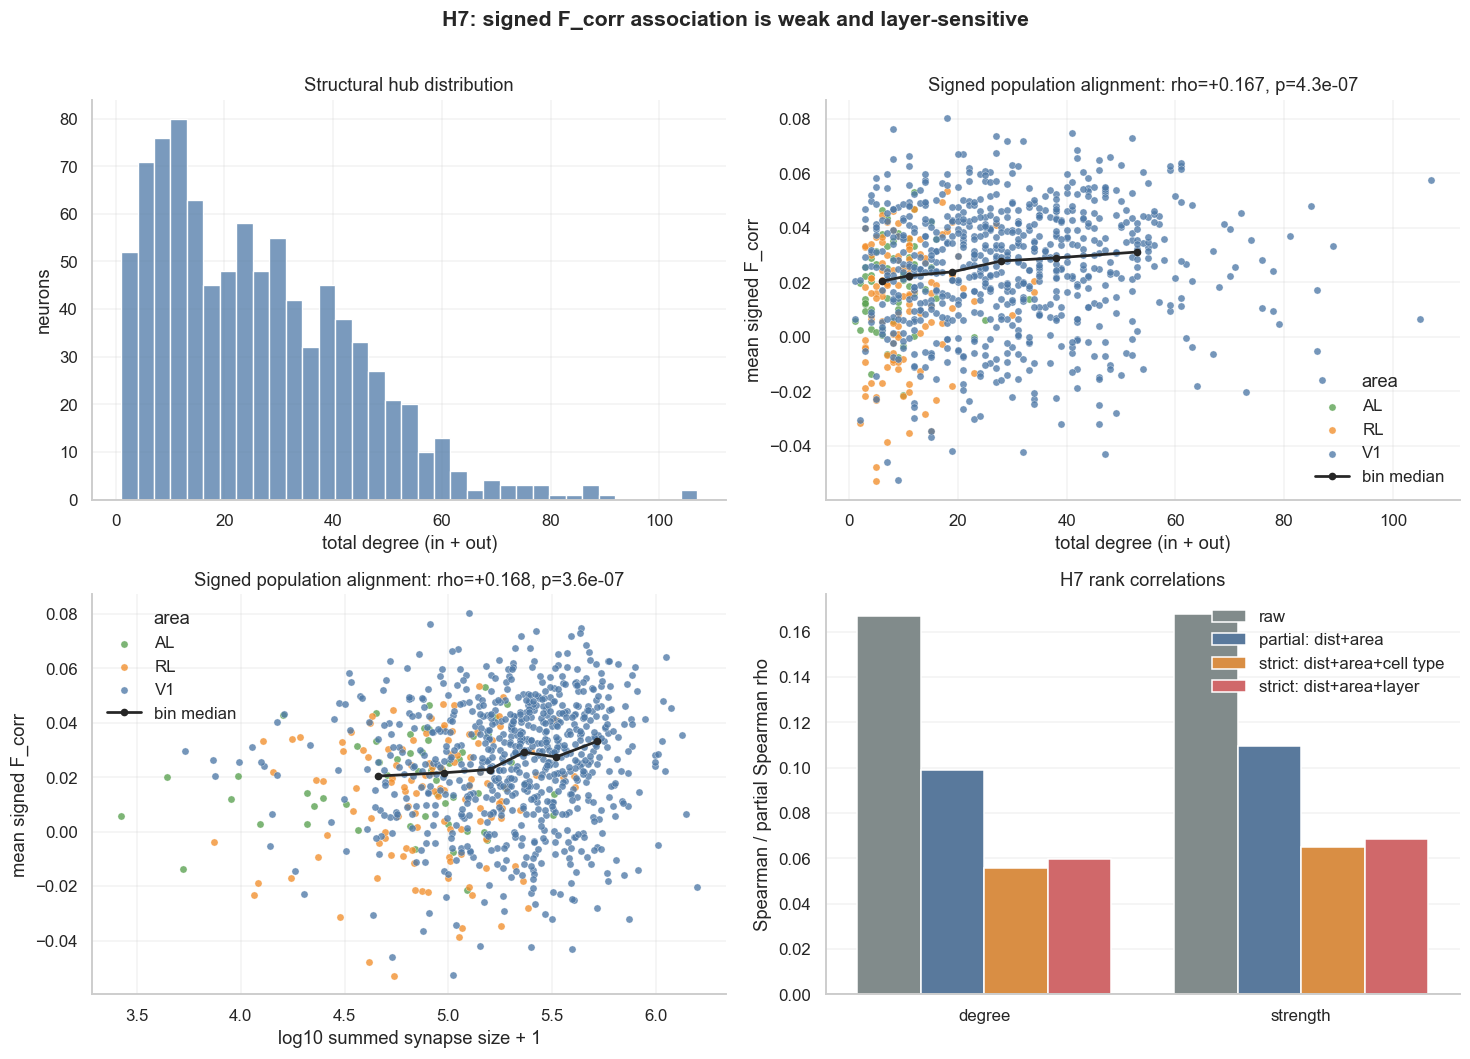

In [7]:
plot_df = hub_metrics[hub_metrics.valid_function].copy()
coef_df = h7_summary[
    (h7_summary.cohort == 'all_906')
    & (h7_summary.functional_metric == 'mean_fcorr_signed')
    & (h7_summary.structural_metric.isin(['total_degree', 'total_strength']))
    & (h7_summary.controls.isin(['raw', 'distance+area', 'distance+area+cell_type', 'distance+area+layer']))
].copy()
coef_df['metric_label'] = coef_df.structural_metric.map({
    'total_degree': 'degree',
    'total_strength': 'strength',
})
coef_df['control_label'] = coef_df.controls.map({
    'raw': 'raw',
    'distance+area': 'partial: dist+area',
    'distance+area+cell_type': 'strict: dist+area+cell type',
    'distance+area+layer': 'strict: dist+area+layer',
})

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))
ax = axes[0, 0]
sns.histplot(plot_df.total_degree, bins=35, color='#4E79A7', ax=ax)
ax.set(title='Structural hub distribution', xlabel='total degree (in + out)', ylabel='neurons')

for ax, xcol, xlabel in [
    (axes[0, 1], 'total_degree', 'total degree (in + out)'),
    (axes[1, 0], 'total_strength', 'log10 summed synapse size + 1'),
]:
    x = plot_df[xcol].to_numpy(dtype=float)
    x_plot = np.log10(x + 1) if xcol == 'total_strength' else x
    for area_name, sub in plot_df.groupby('brain_area'):
        sx = sub[xcol].to_numpy(dtype=float)
        sx = np.log10(sx + 1) if xcol == 'total_strength' else sx
        ax.scatter(
            sx,
            sub.mean_fcorr_signed,
            s=22,
            alpha=0.78,
            linewidths=0.25,
            edgecolor='white',
            color=PAL_AREA.get(area_name, '0.45'),
            label=area_name,
        )
    trend = pd.DataFrame({'x': x_plot, 'y': plot_df.mean_fcorr_signed}).copy()
    trend['bin'] = pd.qcut(trend.x, 6, duplicates='drop')
    trend = trend.groupby('bin', observed=False).agg(x=('x', 'median'), y=('y', 'median')).reset_index(drop=True)
    ax.plot(trend.x, trend.y, color='0.15', lw=1.8, marker='o', ms=4, label='bin median')
    rho = coef_df[(coef_df.structural_metric == xcol) & (coef_df.controls == 'raw')].rho.iloc[0]
    p = coef_df[(coef_df.structural_metric == xcol) & (coef_df.controls == 'raw')].p_value.iloc[0]
    ax.set(title=f'Signed population alignment: rho={rho:+.3f}, p={p:.1e}', xlabel=xlabel, ylabel='mean signed F_corr')
    ax.legend(title='area', frameon=False, loc='best')

ax = axes[1, 1]
sns.barplot(
    data=coef_df,
    x='metric_label',
    y='rho',
    hue='control_label',
    palette=['#7f8c8d', '#4E79A7', '#F28E2B', '#E15759'],
    ax=ax,
)
ax.axhline(0, color='0.2', lw=0.8)
ax.set(title='H7 rank correlations', xlabel='', ylabel='Spearman / partial Spearman rho')
ax.legend(title='', frameon=False)

fig.suptitle('H7: signed F_corr association is weak and layer-sensitive', y=1.01, fontsize=14, fontweight='semibold')
plt.tight_layout()
out_fig = OUT_FIG / 'h7_hub_coupling.png'
fig.savefig(out_fig, bbox_inches='tight')
print(f'saved: {out_fig}')
plt.show()


---
## 8. V1-Only and Functional-Metric Sensitivities

Use these tables to decide what belongs in the final report versus appendix. The final claim should lead with the stricter checks: strength beyond degree is null, absolute `F_corr` is null, same-area support vanishes under controls, and thresholded topology is null. Signed `F_corr` can only be described as **positive signal similarity / population-mode alignment to the cohort**. Absolute `F_corr` is the sign-agnostic coupling-magnitude check; if it is null or negative, the notebook should not claim generic functional hubness. The in/out rows test directional tendency, but the `in_strength` stratified permutation is marginal, so avoid firm input-hub language. `h7_robustness_diagnostics.csv` contains the stricter checks that most directly challenge H7: strength beyond degree, proper V1-only recomputation, same-area functional means, and pairwise-distance residual diagnostics. A residual metric that still correlates with distance is not a clean distance correction and should be described as such.


In [8]:
sensitivity_view = h7_summary[
    (h7_summary.structural_metric.isin(['total_degree', 'total_strength', 'in_degree', 'out_degree', 'in_strength', 'out_strength']))
    & (h7_summary.controls.isin(['raw', 'distance', 'distance+area', 'distance+area+cell_type', 'distance+area+layer']))
].copy()
sensitivity_view = sensitivity_view.sort_values([
    'functional_metric', 'cohort', 'structural_metric', 'controls'
])
key_sensitivity = sensitivity_view[
    sensitivity_view.functional_metric.isin(['mean_fcorr_signed', 'mean_fcorr_abs'])
    & sensitivity_view.structural_metric.isin(['total_degree', 'total_strength', 'in_strength', 'out_strength'])
    & sensitivity_view.controls.isin(['distance+area', 'distance+area+cell_type', 'distance+area+layer'])
].copy()
print(key_sensitivity.to_string(index=False))
h7_robustness


 cohort functional_metric structural_metric                controls                test_role       rho  p_value  n_neurons  rank_variance_approx  q_bh_all_tests
all_906    mean_fcorr_abs       in_strength           distance+area              exploratory -0.086663 0.009058        906              0.007510        0.037057
all_906    mean_fcorr_abs       in_strength distance+area+cell_type              exploratory -0.077500 0.019647        906              0.006006        0.063150
all_906    mean_fcorr_abs       in_strength     distance+area+layer              exploratory -0.081968 0.013588        906              0.006719        0.050954
all_906    mean_fcorr_abs      out_strength           distance+area              exploratory  0.029693 0.372009        906              0.000882        0.471561
all_906    mean_fcorr_abs      out_strength distance+area+cell_type              exploratory  0.043258 0.193308        906              0.001871        0.316322
all_906    mean_fcorr_abs      out

,analysis,structural_metric,functional_metric,controls,rho,rank_variance_approx,p_value,n_neurons
0,strength beyond degree,total_strength,mean_fcorr_signed,total_degree,0.032706,0.001070,3.254287e-01,906
1,strength beyond degree,total_strength,mean_fcorr_signed,mean_dist_um+brain_area+total_degree,0.046779,0.002188,1.594707e-01,906
2,cell-type strict control,total_strength,mean_fcorr_signed,mean_dist_um+brain_area+cell_type,0.064967,0.004221,5.060010e-02,906
3,same-area functional mean,total_strength,mean_fcorr_same_area,raw,-0.120596,0.014543,2.745595e-04,906
4,same-area functional mean,total_strength,mean_fcorr_same_area,mean_dist_same_area+brain_area,0.018606,0.000346,5.759541e-01,906
5,same-area functional mean,total_strength,mean_fcorr_same_area,mean_dist_same_area+brain_area+layer,-0.006129,0.000038,8.538250e-01,906
6,pair-distance residual diagnostic,mean_fcorr_pairdist_resid,mean_dist_um,raw,0.217668,0.047379,3.536745e-11,906
7,pair-distance residual diagnostic,total_strength,mean_fcorr_pairdist_resid,raw,-0.050279,0.002528,1.304704e-01,906
8,V1 recomputed functional mean; full structural...,total_strength,mean_fcorr_subset,raw,0.073940,0.005467,4.611852e-02,728
9,V1 recomputed functional mean; full structural...,total_strength,mean_fcorr_subset,mean_dist_subset,0.041740,0.001742,2.606893e-01,728


---
## 9. Exploratory Topology Sensitivity

This section asks a narrower version of the topology question: if the functional graph is thresholded to match the structural graph density, do node degrees and clustering resemble structural topology? This is exploratory because functional topology depends on the threshold, but it is still important. If the rank coupling is near zero here, the honest interpretation is that H7's mean-`F_corr` result does **not** translate into similar graph topology under thresholded graph comparisons.

In [9]:
def top_k_functional_adjacency(F_corr, k, valid_mask=None, positive_only=True):
    n = F_corr.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    vals = F_corr[iu, ju]
    mask = np.isfinite(vals)
    if valid_mask is not None:
        mask &= valid_mask[iu] & valid_mask[ju]
    if positive_only:
        mask &= vals > 0
    iu, ju, vals = iu[mask], ju[mask], vals[mask]
    k = int(min(k, len(vals)))
    if k <= 0:
        return np.zeros((n, n), dtype=bool), np.full((n, n), np.nan)
    keep = np.argpartition(vals, -k)[-k:]
    A = np.zeros((n, n), dtype=bool)
    W = np.full((n, n), np.nan)
    A[iu[keep], ju[keep]] = True
    A[ju[keep], iu[keep]] = True
    W[iu[keep], ju[keep]] = vals[keep]
    W[ju[keep], iu[keep]] = vals[keep]
    return A, W

A_struct_und = ((C_strength + C_strength.T) > 0).toarray().astype(bool)
np.fill_diagonal(A_struct_und, False)
struct_degree_und = A_struct_und.sum(axis=1)
struct_edges_und = int(A_struct_und[np.triu_indices(N, k=1)].sum())
possible_edges = N * (N - 1) // 2
struct_density_und = struct_edges_und / possible_edges
struct_clustering = nx.average_clustering(nx.from_numpy_array(A_struct_und))

rows = []
for mult in [0.5, 1.0, 2.0, 4.0]:
    k = max(1, int(round(struct_edges_und * mult)))
    A_func, W_func = top_k_functional_adjacency(F_corr, k, valid_mask=valid, positive_only=True)
    func_degree = A_func.sum(axis=1)
    func_strength = np.nansum(np.where(A_func, W_func, 0.0), axis=1)
    rho_deg, p_deg = spearmanr(struct_degree_und[valid], func_degree[valid])
    rho_str, p_str = spearmanr(hub_metrics.loc[valid, 'total_strength'], func_strength[valid])
    func_clustering = nx.average_clustering(nx.from_numpy_array(A_func))
    rows.append({
        'density_multiplier': mult,
        'functional_edges': int(A_func[np.triu_indices(N, k=1)].sum()),
        'functional_density': float(A_func[np.triu_indices(N, k=1)].sum() / possible_edges),
        'structural_edges_undirected': struct_edges_und,
        'structural_density_undirected': struct_density_und,
        'spearman_struct_degree_vs_functional_degree': float(rho_deg),
        'p_degree': float(p_deg),
        'spearman_struct_strength_vs_functional_strength': float(rho_str),
        'p_strength': float(p_str),
        'structural_clustering': float(struct_clustering),
        'functional_clustering': float(func_clustering),
    })

topology = pd.DataFrame(rows)
out_topology = OUT_TBL / 'h7_topology_sensitivity.csv'
topology.to_csv(out_topology, index=False)
print(f'saved: {out_topology}')
topology


saved: outputs\tables\h7_topology_sensitivity.csv


,density_multiplier,functional_edges,functional_density,structural_edges_undirected,structural_density_undirected,spearman_struct_degree_vs_functional_degree,p_degree,spearman_struct_strength_vs_functional_strength,p_strength,structural_clustering,functional_clustering
0,0.5,5790,0.014123,11580,0.028246,-0.003324,0.920414,-0.001005,0.975891,0.070919,0.268704
1,1.0,11580,0.028246,11580,0.028246,0.008211,0.805047,0.011389,0.732099,0.070919,0.287253
2,2.0,23160,0.056493,11580,0.028246,0.006027,0.856244,0.010923,0.742654,0.070919,0.300804
3,4.0,46320,0.112985,11580,0.028246,0.029663,0.372489,0.031480,0.343916,0.070919,0.331571


saved: outputs\figures\h7_topology_sensitivity.png


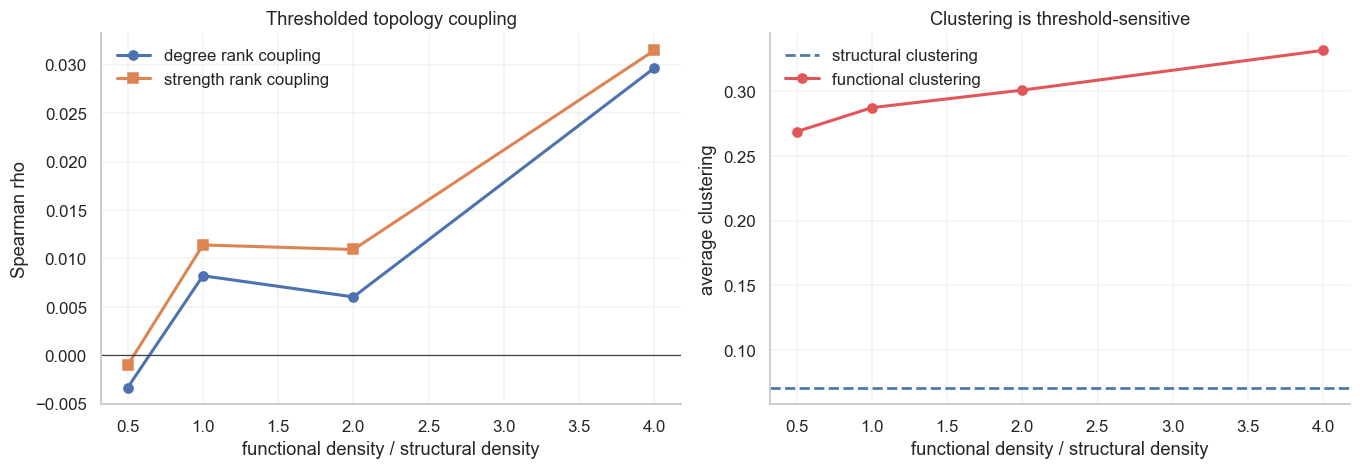

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
ax.plot(
    topology.density_multiplier,
    topology.spearman_struct_degree_vs_functional_degree,
    marker='o',
    lw=2,
    label='degree rank coupling',
)
ax.plot(
    topology.density_multiplier,
    topology.spearman_struct_strength_vs_functional_strength,
    marker='s',
    lw=2,
    label='strength rank coupling',
)
ax.axhline(0, color='0.25', lw=0.8)
ax.set(xlabel='functional density / structural density', ylabel='Spearman rho', title='Thresholded topology coupling')
ax.legend(frameon=False)

ax = axes[1]
ax.axhline(struct_clustering, color='#4E79A7', ls='--', lw=1.8, label='structural clustering')
ax.plot(
    topology.density_multiplier,
    topology.functional_clustering,
    color='#E15759',
    marker='o',
    lw=2,
    label='functional clustering',
)
ax.set(xlabel='functional density / structural density', ylabel='average clustering', title='Clustering is threshold-sensitive')
ax.legend(frameon=False)

plt.tight_layout()
out_fig = OUT_FIG / 'h7_topology_sensitivity.png'
fig.savefig(out_fig, bbox_inches='tight')
print(f'saved: {out_fig}')
plt.show()


---
## 10. H7 Interpretation Draft

Use this language only after rerunning the notebook top to bottom and confirming the saved `h7_summary.csv` values:

> The broad H7 hypothesis is not strongly supported in the 906-neuron excitatory oracle-response cohort. The synapse-size structural strength proxy adds no detectable variance beyond binary connectivity, and structural hubness is not associated with sign-agnostic absolute `F_corr` or thresholded functional graph topology. The narrow signed result is detectable but weak: `total_strength` versus mean signed `F_corr`, controlling for distance and area, has `rho` about +0.11 (`rho^2` about 0.012, roughly 1% rank variance). This should be interpreted as slight signed population-response alignment among neurons with higher summed synapse size, not as evidence that structural hubs are functional hubs. The effect is degree-like rather than synapse-size-specific, weakened by layer/cell-type controls, absent for same-area and absolute-coupling definitions, and not resolved by the pair-distance residual diagnostic because that residual remains distance-structured at the node level. Directional analyses suggest an input-side tendency, but the area x layer stratified permutation for `in_strength` is marginal, so this should remain a caveat rather than a headline.
